Synthetic Data Generation

This step creates a simulated panel dataset of borrower credit states over time.
Each borrower begins in an initial state and transitions month-to-month according to a predefined transition matrix, forming realistic credit risk trajectories.

In [8]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_borrowers = 1000
n_months = 24

states = ["Current", "30_DPD", "60_DPD", "Default", "Recovery"]

transition_matrix = {
    "Current":  [0.88, 0.08, 0.02, 0.01, 0.01],
    "30_DPD":   [0.35, 0.40, 0.15, 0.07, 0.03],
    "60_DPD":   [0.15, 0.25, 0.35, 0.20, 0.05],
    "Default":  [0.00, 0.00, 0.00, 0.90, 0.10],
    "Recovery": [0.50, 0.20, 0.10, 0.05, 0.15],
}

initial_probs = [0.85, 0.08, 0.04, 0.02, 0.01]

data = []

for borrower_id in range(1, n_borrowers + 1):
    current_state = np.random.choice(states, p=initial_probs)
    
    for month in range(1, n_months + 1):
        data.append([borrower_id, month, current_state])
        
        next_probs = transition_matrix[current_state]
        current_state = np.random.choice(states, p=next_probs)

df = pd.DataFrame(data, columns=["borrower_id", "month", "state"])

df.head(10)

,borrower_id,month,state
0,1,1,Current
1,1,2,30_DPD
2,1,3,30_DPD
3,1,4,30_DPD
4,1,5,Current
5,1,6,Current
6,1,7,Current
7,1,8,Current
8,1,9,Current
9,1,10,Current


State Distribution Overview

This summarizes the proportion of borrower-month observations in each credit state, providing a baseline view of how the simulated portfolio is distributed across risk categories.

In [10]:
df["state"].value_counts(normalize=True).round(3)

state
Current     0.629
Default     0.168
30_DPD      0.116
60_DPD      0.055
Recovery    0.033
Name: proportion, dtype: float64

Estimating Transition Probabilities

This step constructs the empirical transition matrix from the simulated data. For each borrower, consecutive states are paired to identify transitions, which are then aggregated into counts and converted into probabilities. Each row represents the probability distribution of next states conditional on the current state.

In [13]:
df_sorted = df.sort_values(["borrower_id", "month"]).copy()

df_sorted["next_state"] = df_sorted.groupby("borrower_id")["state"].shift(-1)

transitions = df_sorted.dropna(subset=["next_state"])

transition_counts = pd.crosstab(
    transitions["state"],
    transitions["next_state"]
)

transition_probs = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

transition_probs.round(3)

next_state,30_DPD,60_DPD,Current,Default,Recovery
state,,,,,
30_DPD,0.407,0.158,0.338,0.069,0.028
60_DPD,0.238,0.362,0.141,0.195,0.064
Current,0.081,0.022,0.879,0.010,0.009
Default,0.000,0.000,0.000,0.899,0.101
Recovery,0.193,0.104,0.512,0.051,0.141


Transition Matrix Interpretation

This heatmap shows the probability of transitioning from each current state (rows) to a next state (columns). Brighter cells indicate higher transition probabilities.

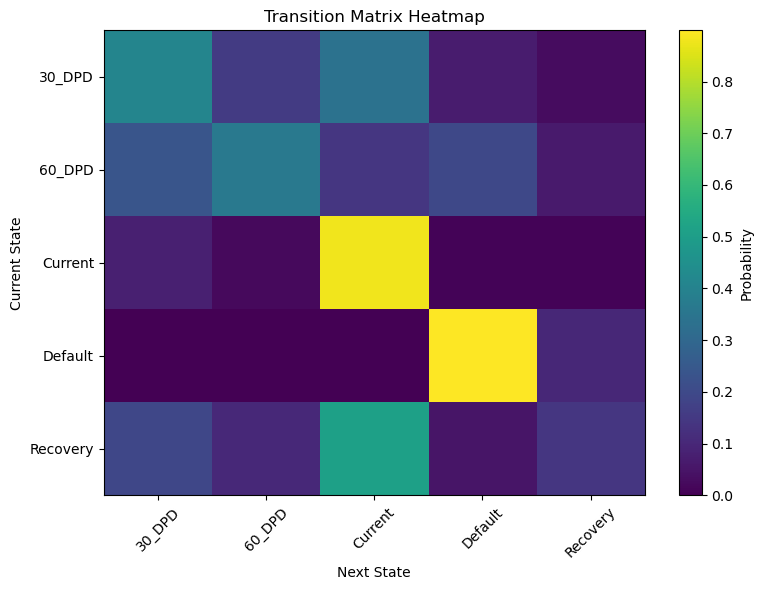

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(transition_probs, aspect="auto")

plt.colorbar(label="Probability")

plt.xticks(range(len(transition_probs.columns)), transition_probs.columns, rotation=45)
plt.yticks(range(len(transition_probs.index)), transition_probs.index)

plt.title("Transition Matrix Heatmap")
plt.xlabel("Next State")
plt.ylabel("Current State")

plt.tight_layout()
plt.show()

Monte Carlo Simulation of Borrower Paths

This step simulates future borrower trajectories using the estimated transition matrix.
For each simulated borrower, states are drawn sequentially based on current-state transition probabilities.
This allows estimation of path-dependent outcomes such as the probability of default within a fixed horizon.

In [16]:
import numpy as np

states = list(transition_probs.index)

def simulate_path(start_state, transition_probs, n_steps):
    path = [start_state]
    current_state = start_state
    
    for _ in range(n_steps):
        probs = transition_probs.loc[current_state].values
        next_state = np.random.choice(states, p=probs)
        path.append(next_state)
        current_state = next_state
        
    return path

n_simulations = 1000
n_steps = 24

simulated_paths = []

for _ in range(n_simulations):
    start_state = np.random.choice(states)
    path = simulate_path(start_state, transition_probs, n_steps)
    simulated_paths.append(path)

Estimating Default Risk

We compute the share of simulated borrowers who enter the Default state at least once within 24 months.
This provides an estimate of cumulative default risk under the modeled transition dynamics.

In [17]:
default_count = 0

for path in simulated_paths:
    if "Default" in path:
        default_count += 1

default_probability = default_count / n_simulations
default_probability

0.664

In [20]:
import pandas as pd

sim_df = pd.DataFrame(simulated_paths)
sim_df.columns = [f"month_{i}" for i in range(sim_df.shape[1])]

default_by_month = (sim_df == "Default").mean()
default_by_month

month_0     0.206
month_1     0.249
month_2     0.266
month_3     0.266
month_4     0.273
month_5     0.270
month_6     0.256
month_7     0.247
month_8     0.247
month_9     0.246
month_10    0.239
month_11    0.244
month_12    0.240
month_13    0.243
month_14    0.246
month_15    0.252
month_16    0.235
month_17    0.239
month_18    0.226
month_19    0.228
month_20    0.230
month_21    0.233
month_22    0.236
month_23    0.230
month_24    0.227
dtype: float64

Default Probability Over Time

This plot shows the probability that a borrower is in the Default state at each point in time based on simulated paths. The system converges toward a stable distribution, reflecting both persistence in default and the possibility of recovery.

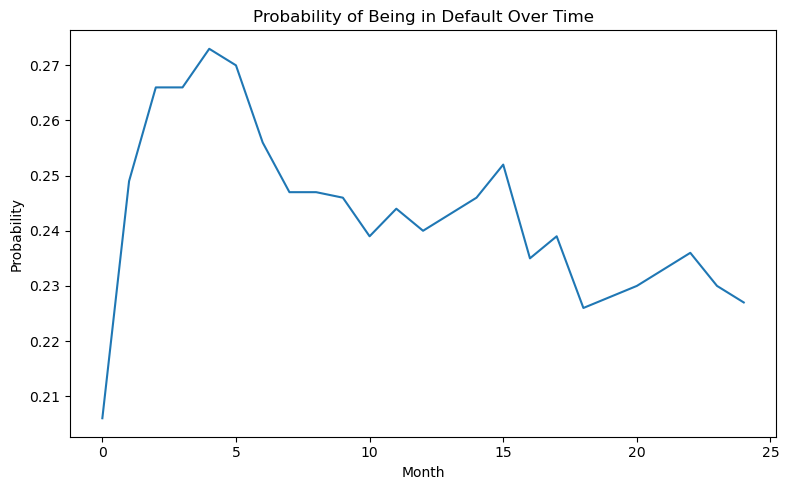

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(default_by_month.values)

plt.title("Probability of Being in Default Over Time")
plt.xlabel("Month")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()

In [22]:
import numpy as np

# True if borrower has defaulted at or before each month
cumulative_default = (sim_df == "Default").cummax(axis=1)

cumulative_default_by_month = cumulative_default.mean()
cumulative_default_by_month

month_0     0.206
month_1     0.270
month_2     0.310
month_3     0.339
month_4     0.365
month_5     0.384
month_6     0.398
month_7     0.413
month_8     0.433
month_9     0.446
month_10    0.468
month_11    0.486
month_12    0.503
month_13    0.522
month_14    0.539
month_15    0.556
month_16    0.566
month_17    0.581
month_18    0.594
month_19    0.609
month_20    0.623
month_21    0.634
month_22    0.642
month_23    0.654
month_24    0.664
dtype: float64

Cumulative Default Risk

This plot shows the probability that a borrower has entered default by each month. The curve increases over time and approaches a plateau, indicating that default risk accumulates early and stabilizes as fewer new defaults occur in later periods. Default risk is concentrated in the early months, with the steepest increase occurring in the initial periods. This suggests that early-stage intervention is critical, as borrowers who remain current beyond this window are less likely to default later.

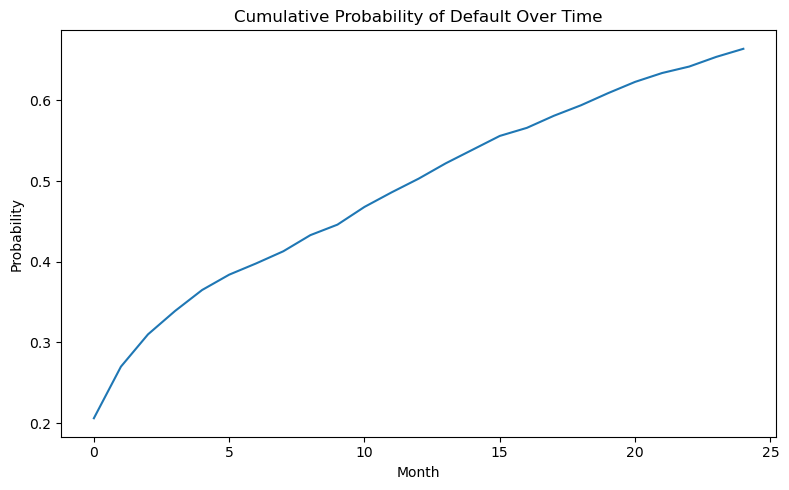

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(cumulative_default_by_month.values)

plt.title("Cumulative Probability of Default Over Time")
plt.xlabel("Month")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()

In [24]:
improved_transition_probs = transition_probs.copy()

# Improve recovery from delinquent states
improved_transition_probs.loc["30_DPD", "Current"] += 0.10
improved_transition_probs.loc["30_DPD", "30_DPD"] -= 0.10

improved_transition_probs.loc["60_DPD", "Current"] += 0.10
improved_transition_probs.loc["60_DPD", "60_DPD"] -= 0.10

# Ensure rows still sum to 1
improved_transition_probs = improved_transition_probs.div(
    improved_transition_probs.sum(axis=1), axis=0
)

In [25]:
improved_paths = []

for _ in range(n_simulations):
    start_state = np.random.choice(states)
    path = simulate_path(start_state, improved_transition_probs, n_steps)
    improved_paths.append(path)

In [26]:
improved_df = pd.DataFrame(improved_paths)
improved_df.columns = sim_df.columns

improved_cum_default = (improved_df == "Default").cummax(axis=1).mean()

Scenario Analysis: Improved Recovery

This scenario increases the probability that delinquent borrowers return to a current state. The simulation shows how targeted intervention can reduce cumulative default risk over time.

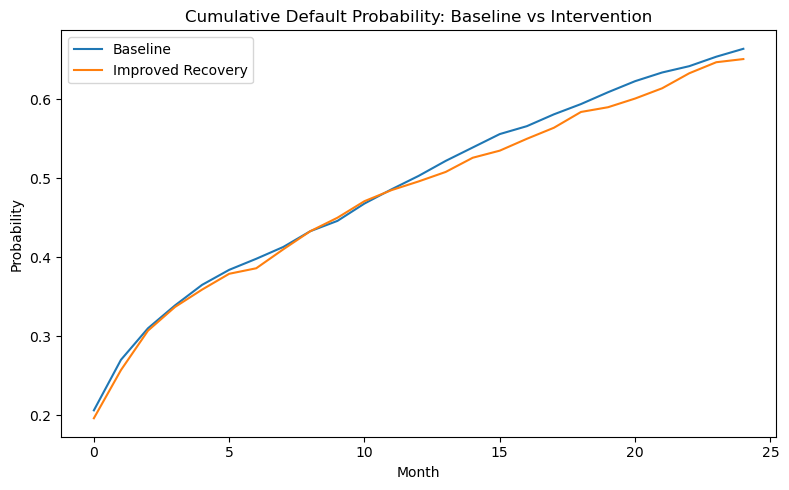

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(cumulative_default_by_month.values, label="Baseline")
plt.plot(improved_cum_default.values, label="Improved Recovery")

plt.title("Cumulative Default Probability: Baseline vs Intervention")
plt.xlabel("Month")
plt.ylabel("Probability")

plt.legend()
plt.tight_layout()
plt.show()

The intervention reduces cumulative default risk by approximately 1.3 percentage points over 24 months, with the gap widening over time. Although the immediate effect is small, improvements in recovery transitions compound, leading to a persistent reduction in long-run default exposure.

In [31]:
reduction_pp = (
    cumulative_default_by_month.iloc[-1]
    - improved_cum_default.iloc[-1]
)

round(reduction_pp * 100, 2)
print(f"Reduction in default risk: {reduction_pp * 100:.2f} percentage points")

Reduction in default risk: 1.30 percentage points


Project Summary

This project models borrower credit risk dynamics using a Markov chain framework and Monte Carlo simulation. The results show that default risk accumulates rapidly in early periods and stabilizes over time, highlighting the importance of early intervention.

A scenario improving recovery transitions reduces cumulative default risk by approximately 1.3 percentage points over 24 months. Although modest in the short term, the effect compounds over time, demonstrating how incremental improvements in borrower outcomes can lead to meaningful reductions in long-run risk exposure.

In [34]:
plt.savefig("outputs/figures/cumulative_default_comparison.png")
plt.show()

<Figure size 640x480 with 0 Axes>